# Mean-reversion tests — **AR(1) tradeable universe**

**Purpose in the two-notebook story:** restrict Test 3 to tickers that pass **Test 2** as mean-reverting in the idiosyncratic residual: **φ < 0** and **p-value < AR1_MAX_P** (default 0.10). Typical count is on the order of **~67 names** (exact count is printed after Test 2).

**Pair with:** [`3.1-ag-mean-reversion-narrative-wide.ipynb`](3.1-ag-mean-reversion-narrative-wide.ipynb) (`USE_AR1_UNIVERSE = False`) for the **full ~200-name baseline**.

**Narrative:** *Where the model says mean reversion is statistically present, the z-signal is stronger and represents the **main tradeable** specification.*

---

Same pipeline as **3.1** / **3.0**: improved PCA outputs from **2.1**. **Test 1–4** code is identical; **`USE_AR1_UNIVERSE = True`** narrows **zs_port / r_trade** for portfolio construction (and optionally the AR(1)-filtered regression line in Test 1 when that cell runs).



In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

PROCESSED = "data/processed"

In [15]:
# --- Must match OUTPUT_SUFFIX in notebook 2.1 (derived as _L{L}_K{K}_M{M}) ---
PCA_OUTPUT_SUFFIX = "_L126_K10_M20"

# Forward return for L–S portfolio: sum of log returns from t+1 .. t+H (plan: try 5,7,10,15)
HOLDING_DAYS = 10

COST_BPS_PER_SIDE = 1.0

# "decile" | "tail_quantile" | "threshold" (long z < -Z_THRESHOLD, short z > Z_THRESHOLD)
PORTFOLIO_MODE = "threshold"
Z_THRESHOLD = 1.5  # sweep 1.0, 1.5, 2.0 across runs
N_DECILES = 10
TAIL_Q = 0.05

# "equal" | "inv_vol" | "signal" | "signal_abs_z" (|z| within each leg; signal == signal_abs_z)
WEIGHTING = "equal"
INV_VOL_LOOKBACK = 20

# Restrict portfolio (and optional Test 1 alt) to AR(1) mean-reverting names (after Test 2 cell runs)
USE_AR1_UNIVERSE = True
AR1_MAX_P = 0.10

# Extra Test 1: stock-demeaned y (approx. FE); horizon-matched y = r_fwd_H vs HOLDING_DAYS
RUN_TEST1_DEMEAN = True
RUN_TEST1_HORIZON_MATCH = True

# Optional: also report OLS with cluster on ticker (point estimates match default OLS)
RUN_TEST1_CLUSTER_TICKER = False

# If True, print gross L–S for each threshold in Z_THRESHOLD_SWEEP (same HOLDING_DAYS / costs)
RUN_Z_THRESHOLD_SWEEP = False
Z_THRESHOLD_SWEEP = (1.0, 1.5, 2.0)

In [16]:
log_returns = pd.read_parquet(f"{PROCESSED}/log_returns.parquet")
residuals   = pd.read_parquet(f"{PROCESSED}/residual_returns{PCA_OUTPUT_SUFFIX}.parquet")
zscores     = pd.read_parquet(f"{PROCESSED}/residual_zscores{PCA_OUTPUT_SUFFIX}.parquet")

# Restrict log_returns to the clean universe from notebook 2
shared_cols = residuals.columns.intersection(log_returns.columns)
log_returns = log_returns[shared_cols]

print(f"Log returns : {log_returns.shape}")
print(f"Residuals   : {residuals.shape}  (suffix {PCA_OUTPUT_SUFFIX})")
print(f"Z-scores    : {zscores.shape}")

Log returns : (3734, 200)
Residuals   : (3608, 200)  (suffix _L126_K10_M20)
Z-scores    : (3588, 200)


In [17]:
# --- Align PCA outputs to calendar dates ------------------------------------
# In rolling_pca_residuals (notebook 2.x), each row stores ε for the *last day inside
# the L-day window* (day t-1 in the loop) but the DataFrame label is the window end (day t).
# Relabel so index date t means ε_{i,t}. Z-scores inherit the same wrong labels in parquet;
# they are the same rows as residuals (possibly fewer leading rows after dropna).
if "pd" not in globals():
    import pandas as pd
if any(n not in globals() for n in ("log_returns", "residuals", "zscores")):
    _proc = globals().get("PROCESSED", "data/processed")
    _suf = globals().get("PCA_OUTPUT_SUFFIX", "_L126_K10_M20")
    log_returns = pd.read_parquet(f"{_proc}/log_returns.parquet")
    residuals = pd.read_parquet(f"{_proc}/residual_returns{_suf}.parquet")
    zscores = pd.read_parquet(f"{_proc}/residual_zscores{_suf}.parquet")
    _cols = residuals.columns.intersection(log_returns.columns)
    log_returns = log_returns[_cols]
if "HOLDING_DAYS" not in globals():
    HOLDING_DAYS = 10

L_pca = len(log_returns.index) - len(residuals.index)
if L_pca <= 0:
    raise ValueError("log_returns must be longer than residuals (PCA window L).")
eps_dates = log_returns.index[L_pca - 1 : -1]
if len(eps_dates) != len(residuals.index):
    raise ValueError(
        f"Residual date fix mismatch: len(log_returns)={len(log_returns)}, "
        f"len(residuals)={len(residuals)} → expected {len(eps_dates)} residual rows."
    )
_wrong_idx = residuals.index.copy()  # PCA parquet labels (one day ahead of ε)
residuals = residuals.set_axis(eps_dates, axis=0)
z_first_pos = _wrong_idx.get_loc(zscores.index[0])
if isinstance(z_first_pos, slice):
    raise ValueError("Unexpected duplicate residual index when aligning z-scores.")
zscores = zscores.set_axis(eps_dates[z_first_pos : z_first_pos + len(zscores)], axis=0)

# Align for predictive regressions (1-day horizon)
# Row t: z_{i,t} is known after close t; r_next / eps_next are r_{i,t+1} and ε_{i,t+1}.
r_next   = log_returns.shift(-1).reindex(zscores.index)
eps_next = residuals.shift(-1).reindex(zscores.index)

# Multi-day forward log return for portfolio tests: sum of daily log returns from t+1 … t+h
# (≈ log gross return from close t to close t+h if you compound daily closes). Last h rows are NaN.
def forward_log_return_sum(r: pd.DataFrame, h: int) -> pd.DataFrame:
    out = r.shift(-1)
    for j in range(2, h + 1):
        out = out + r.shift(-j)
    return out

r_trade = forward_log_return_sum(log_returns, HOLDING_DAYS).reindex(zscores.index)

# Stack into long-format panel + H-day forward return for horizon-matched Test 1
panel = pd.concat({
    "z_score" : zscores.stack(),
    "r_next"  : r_next.stack(),
    "eps_next": eps_next.stack(),
}, axis=1).dropna()
panel["r_fwd_H"] = r_trade.stack()
panel = panel.dropna().reset_index()
panel.columns = ["date", "ticker", "z_score", "r_next", "eps_next", "r_fwd_H"]

print(f"Panel observations: {len(panel):,}")
print(f"Date range         : {panel['date'].min().date()}  →  {panel['date'].max().date()}")
print(f"Portfolio horizon  : {HOLDING_DAYS}-day forward log-return sum (r_trade)")
panel.head()

Panel observations: 715,800
Date range         : 2012-01-24  →  2026-04-17
Portfolio horizon  : 10-day forward log-return sum (r_trade)


,date,ticker,z_score,r_next,eps_next,r_fwd_H
0,2012-01-24,NVDA,1.007079,-0.006042,-0.010559,0.052163
1,2012-01-24,TSLA,0.505830,0.019860,0.016492,0.141885
2,2012-01-24,AAPL,-3.084159,0.048311,0.031832,0.096754
3,2012-01-24,MSFT,-1.543125,0.007470,-0.000896,0.033845
4,2012-01-24,AMZN,-0.034149,0.004269,0.003913,0.008018


---
## Test 1 — Predictive Regression

We estimate two pooled panel regressions:

**Return regression** (more directly tradable):
$$r_{i,t+1} = a + b \cdot z_{i,t} + u_{i,t+1}$$

**Residual regression** (more directly tied to the model):
$$\varepsilon_{i,t+1} = a + b \cdot z_{i,t} + u_{i,t+1}$$

Mean reversion predicts $b < 0$: a high z-score today (idiosyncratic outperformance) should predict a lower-than-average return tomorrow.

Standard errors are clustered by date to account for cross-sectional dependence — on any given day, all stock residuals share a common shock.

In [18]:
X = sm.add_constant(panel["z_score"])

# Primary Test 1 (protect this spec): pooled return regression, date-clustered SEs
fit_r = sm.OLS(panel["r_next"], X).fit(
    cov_type="cluster", cov_kwds={"groups": panel["date"]}
)
fit_e = sm.OLS(panel["eps_next"], X).fit(
    cov_type="cluster", cov_kwds={"groups": panel["date"]}
)

# Stock-demeaned y (approx. stock FE) — plan Week 3
fit_r_fe = None
if globals().get("RUN_TEST1_DEMEAN", True):
    panel["r_next_dm"] = panel["r_next"] - panel.groupby("ticker")["r_next"].transform("mean")
    fit_r_fe = sm.OLS(panel["r_next_dm"], X).fit(
        cov_type="cluster", cov_kwds={"groups": panel["date"]}
    )

# Horizon-matched: predict sum of next H daily returns (same H as r_trade / Test 3)
fit_r_H = None
if globals().get("RUN_TEST1_HORIZON_MATCH", True):
    fit_r_H = sm.OLS(panel["r_fwd_H"], X).fit(
        cov_type="cluster", cov_kwds={"groups": panel["date"]}
    )

fit_r_tick = None
if globals().get("RUN_TEST1_CLUSTER_TICKER", False):
    fit_r_tick = sm.OLS(panel["r_next"], X).fit(
        cov_type="cluster", cov_kwds={"groups": panel["ticker"]}
    )

def reg_summary(label, fit):
    b      = fit.params["z_score"]
    t_stat = fit.tvalues["z_score"]
    pval   = fit.pvalues["z_score"]
    r2     = fit.rsquared
    n      = int(fit.nobs)
    stars  = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
    print(f"{label}")
    print(f"  b        = {b:.6f}{stars}")
    print(f"  t-stat   = {t_stat:.3f}")
    print(f"  p-value  = {pval:.4f}")
    print(f"  R²       = {r2:.6f}")
    print(f"  N        = {n:,}")
    print()

reg_summary("Return regression:  r_{i,t+1} = a + b·z_{i,t}", fit_r)
reg_summary("Residual regression: ε_{i,t+1} = a + b·z_{i,t}", fit_e)
if fit_r_fe is not None:
    reg_summary("Return regression (stock-demeaned y):  r̃_{i,t+1} = a + b·z_{i,t}", fit_r_fe)
if fit_r_H is not None:
    reg_summary(
        f"Return regression (H={HOLDING_DAYS}d fwd sum):  r_i,t+1:t+H = a + b·z_{{i,t}}",
        fit_r_H,
    )
if fit_r_tick is not None:
    reg_summary("Return regression (cluster SE by ticker)", fit_r_tick)

Return regression:  r_{i,t+1} = a + b·z_{i,t}
  b        = -0.000082***
  t-stat   = -4.208
  p-value  = 0.0000
  R²       = 0.000029
  N        = 715,800

Residual regression: ε_{i,t+1} = a + b·z_{i,t}
  b        = -0.000085***
  t-stat   = -5.593
  p-value  = 0.0000
  R²       = 0.000081
  N        = 715,800

Return regression (stock-demeaned y):  r̃_{i,t+1} = a + b·z_{i,t}
  b        = -0.000082***
  t-stat   = -4.230
  p-value  = 0.0000
  R²       = 0.000029
  N        = 715,800

Return regression (H=10d fwd sum):  r_i,t+1:t+H = a + b·z_{i,t}
  b        = -0.000079
  t-stat   = -1.474
  p-value  = 0.1404
  R²       = 0.000003
  N        = 715,800



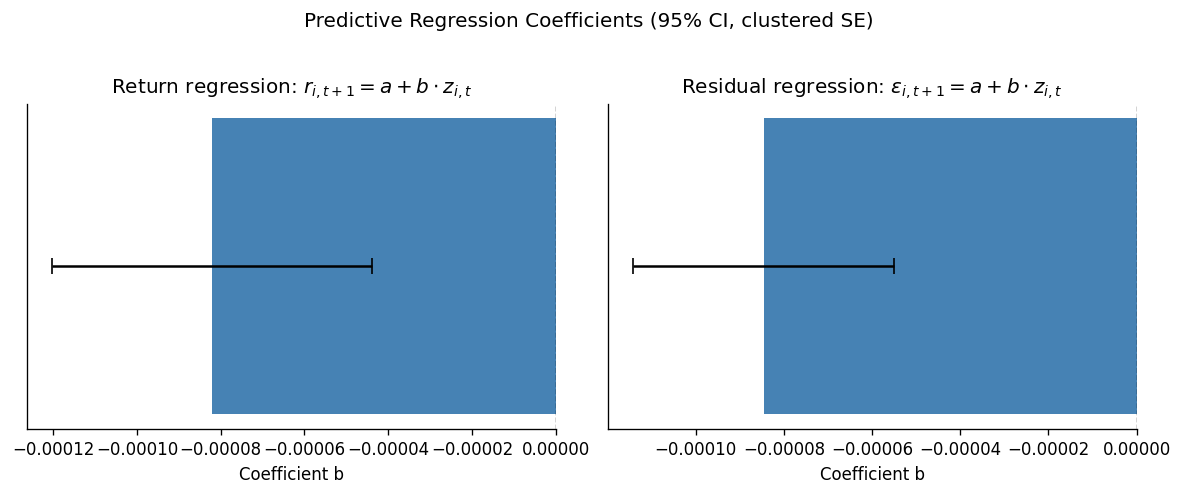

In [19]:
# Coefficient plot — visually confirm b < 0
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, fit, title in zip(
    axes,
    [fit_r, fit_e],
    [r"Return regression: $r_{i,t+1} = a + b \cdot z_{i,t}$",
     r"Residual regression: $\varepsilon_{i,t+1} = a + b \cdot z_{i,t}$"],
):
    b   = fit.params["z_score"]
    ci  = fit.conf_int().loc["z_score"]
    ax.barh([0], [b], color="steelblue" if b < 0 else "crimson", height=0.4)
    ax.errorbar([b], [0], xerr=[[b - ci[0]], [ci[1] - b]], fmt="none", color="black", capsize=5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_yticks([])
    ax.set_xlabel("Coefficient b")
    ax.set_title(title)

plt.suptitle("Predictive Regression Coefficients (95% CI, clustered SE)", y=1.02)
plt.tight_layout()
plt.show()

---
## Test 2 — AR(1) Residual Autocorrelation

For each stock we estimate:
$$\varepsilon_{i,t+1} = a_i + \phi_i \cdot \varepsilon_{i,t} + u_{i,t+1}$$

Mean reversion predicts $\phi_i < 0$. We report the distribution of $\phi_i$ across all stocks, and what fraction are negative and statistically significant.

In [20]:
ar1_results = {}

for ticker in tqdm(residuals.columns, desc="AR(1)"):
    eps = residuals[ticker].dropna()
    df  = pd.DataFrame({"eps_t": eps, "eps_lag": eps.shift(1)}).dropna()
    if len(df) < 50:
        continue
    fit = sm.OLS(df["eps_t"], sm.add_constant(df["eps_lag"])).fit()
    ar1_results[ticker] = {
        "phi"   : fit.params["eps_lag"],
        "tstat" : fit.tvalues["eps_lag"],
        "pvalue": fit.pvalues["eps_lag"],
    }

phi_df = pd.DataFrame(ar1_results).T

neg        = (phi_df["phi"] < 0).mean()
sig_neg    = ((phi_df["phi"] < 0) & (phi_df["pvalue"] < 0.05)).mean()
sig_pos    = ((phi_df["phi"] > 0) & (phi_df["pvalue"] < 0.05)).mean()

print(f"Mean φ                      : {phi_df['phi'].mean():.4f}")
print(f"Median φ                    : {phi_df['phi'].median():.4f}")
print(f"Fraction φ < 0              : {neg:.1%}")
print(f"Fraction φ < 0 & p < 0.05   : {sig_neg:.1%}")
print(f"Fraction φ > 0 & p < 0.05   : {sig_pos:.1%}")

_ar1_p = globals().get("AR1_MAX_P", 0.10)
ar1_tradeable = phi_df[(phi_df["phi"] < 0) & (phi_df["pvalue"] < _ar1_p)].index.tolist()
print(f"AR(1) tradeable (φ<0, p<{_ar1_p}): {len(ar1_tradeable)} tickers")

AR(1): 100%|██████████| 200/200 [00:00<00:00, 572.37it/s]

Mean φ                      : -0.0165
Median φ                    : -0.0171
Fraction φ < 0              : 75.5%
Fraction φ < 0 & p < 0.05   : 25.5%
Fraction φ > 0 & p < 0.05   : 2.0%
AR(1) tradeable (φ<0, p<0.1): 67 tickers


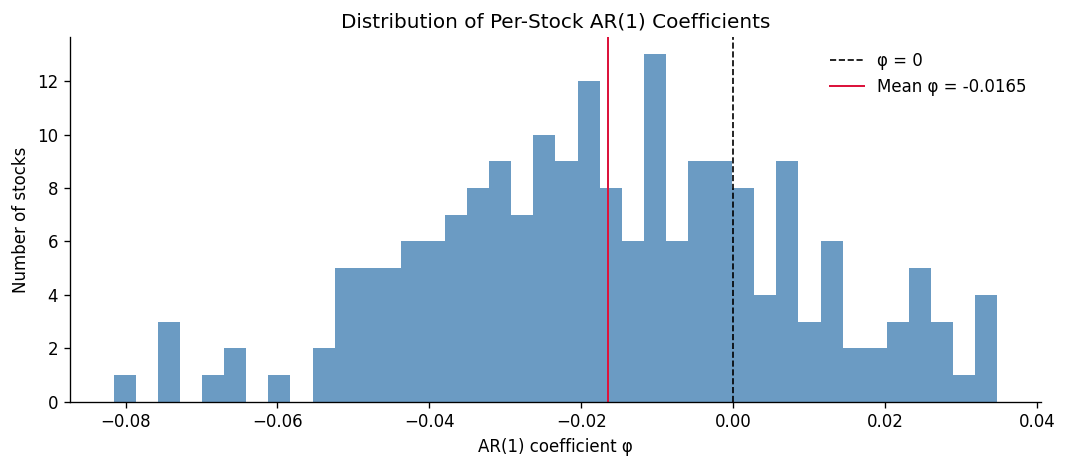

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(phi_df["phi"], bins=40, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(0,                   color="black",  linewidth=1.0, linestyle="--", label="φ = 0")
ax.axvline(phi_df["phi"].mean(), color="crimson", linewidth=1.2, linestyle="-",  label=f"Mean φ = {phi_df['phi'].mean():.4f}")
ax.set_xlabel("AR(1) coefficient φ")
ax.set_ylabel("Number of stocks")
ax.set_title("Distribution of Per-Stock AR(1) Coefficients")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## Test 3 — Long–short portfolio

Use **`PORTFOLIO_MODE`**: `threshold` (long \(z < -\) `Z_THRESHOLD`, short \(z >\) `Z_THRESHOLD`), `decile` (D1 vs D10), or `tail_quantile`. Returns are **`r_trade`**: sum of the next **`HOLDING_DAYS`** log returns. **`WEIGHTING`**: `equal`, `inv_vol`, or `signal_abs_z`. Set **`USE_AR1_UNIVERSE`** to restrict to AR(1)-significant tickers. Gross vs net subtracts a round-trip **`COST_BPS_PER_SIDE`** fee.

In [22]:
# --- Optional: Test 1 on AR(1)-filtered universe ---
fit_r_ar1uni = None
if globals().get("USE_AR1_UNIVERSE", False) and len(ar1_tradeable) > 0:
    p_ar = panel[panel["ticker"].isin(ar1_tradeable)].copy()
    X_ar = sm.add_constant(p_ar["z_score"])
    fit_r_ar1uni = sm.OLS(p_ar["r_next"], X_ar).fit(
        cov_type="cluster", cov_kwds={"groups": p_ar["date"]}
    )
    reg_summary("Return regression (AR(1)-filtered universe)", fit_r_ar1uni)
elif globals().get("USE_AR1_UNIVERSE", False):
    print("USE_AR1_UNIVERSE True but no ar1_tradeable tickers; skip filtered regression.")

trade_cols = list(zscores.columns)
if globals().get("USE_AR1_UNIVERSE", False):
    trade_cols = [c for c in trade_cols if c in ar1_tradeable]
    if len(trade_cols) < 10:
        print(f"Warning: only {len(trade_cols)} AR(1) tradeable names; consider USE_AR1_UNIVERSE=False.")

zs_port = zscores[trade_cols]
rt_port = r_trade[trade_cols]
log_port = log_returns[trade_cols]
vol_look = log_port.rolling(INV_VOL_LOOKBACK).std().shift(1)


def _weighted_mean_return(rv, zv, vv, mask, wmode):
    """vv = vol Series aligned with rv (same index), or None if not inv_vol."""
    rl = rv[mask]
    if len(rl) == 0:
        return float("nan")
    if wmode == "equal":
        wl = pd.Series(1.0, index=rl.index)
    elif wmode == "inv_vol":
        vl = vv[mask]
        wl = 1.0 / vl
    elif wmode in ("signal_abs_z", "signal"):
        zl = zv[mask]
        wl = zl.abs()
    else:
        raise ValueError(wmode)
    wsum = wl.sum()
    if wsum == 0:
        return float(rl.mean())
    return float((rl * (wl / wsum)).sum())


decile_ret_records = []
tail_ls_records = []
threshold_ls_records = []
common_dates = zs_port.index[zs_port.index.isin(rt_port.index)]

for date in tqdm(common_dates[:-1], desc="Portfolio sort"):
    z_row = zs_port.loc[date]
    r_row = rt_port.loc[date]
    v_row = vol_look.loc[date]

    valid = z_row.notna() & r_row.notna()
    if WEIGHTING == "inv_vol":
        valid &= v_row.notna() & v_row.gt(0)

    zv = z_row[valid]
    rv = r_row[valid]
    vv = v_row[valid]

    if PORTFOLIO_MODE == "threshold":
        lm = zv < -Z_THRESHOLD
        sm = zv > Z_THRESHOLD
        if lm.any() and sm.any():
            lret = _weighted_mean_return(rv, zv, vv, lm, WEIGHTING)
            sret = _weighted_mean_return(rv, zv, vv, sm, WEIGHTING)
            threshold_ls_records.append({"date": date, "ret": lret - sret})
        continue

    if len(zv) < N_DECILES * 2:
        continue

    try:
        dec_labels = pd.qcut(zv, q=N_DECILES, labels=False, duplicates="drop")
    except ValueError:
        dec_labels = None

    if dec_labels is not None and PORTFOLIO_MODE == "decile":
        for d in range(N_DECILES):
            mask = dec_labels == d
            if mask.sum() == 0:
                continue
            mu = _weighted_mean_return(rv, zv, vv, mask, WEIGHTING)
            decile_ret_records.append({"date": date, "decile": d + 1, "ret": mu})

    if PORTFOLIO_MODE == "tail_quantile":
        lo, hi = zv.quantile(TAIL_Q), zv.quantile(1 - TAIL_Q)
        lm, sm = zv <= lo, zv >= hi
        if lm.any() and sm.any():
            lret = _weighted_mean_return(rv, zv, vv, lm, WEIGHTING)
            sret = _weighted_mean_return(rv, zv, vv, sm, WEIGHTING)
            tail_ls_records.append({"date": date, "ret": lret - sret})

decile_df = pd.DataFrame(decile_ret_records)
tail_ls_df = pd.DataFrame(tail_ls_records)
threshold_df = pd.DataFrame(threshold_ls_records)

if PORTFOLIO_MODE == "decile" and len(decile_df):
    decile_mean = decile_df.groupby("decile")["ret"].mean() * 1e4
    decile_se = decile_df.groupby("decile")["ret"].sem() * 1e4
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(decile_mean.index, decile_mean.values, yerr=decile_se.values,
           color="steelblue", edgecolor="none", alpha=0.85, capsize=3, error_kw={"linewidth": 0.8})
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_xlabel("Residual Z-Score Decile  (1 = lowest, 10 = highest)")
    ax.set_ylabel(f"Mean {HOLDING_DAYS}d forward return (bps)")
    ax.set_title(f"Z deciles vs {HOLDING_DAYS}d forward return  |  weight={WEIGHTING}")
    ax.set_xticks(range(1, N_DECILES + 1))
    plt.tight_layout()
    plt.show()
    ls_spread_bps = float(decile_mean.iloc[0] - decile_mean.iloc[-1])
    print(f"Long-short spread (D1 − D10, gross): {ls_spread_bps:.2f} bps per rebalance")
elif PORTFOLIO_MODE == "threshold":
    print(f"PORTFOLIO_MODE=threshold (|z|>{Z_THRESHOLD}); decile chart skipped.")
    ls_spread_bps = float("nan")
else:
    ls_spread_bps = float("nan")

if PORTFOLIO_MODE == "decile":
    ls_daily = (
        decile_df[decile_df["decile"] == 1].set_index("date")["ret"]
        - decile_df[decile_df["decile"] == N_DECILES].set_index("date")["ret"]
    ).sort_index()
elif PORTFOLIO_MODE == "tail_quantile":
    ls_daily = tail_ls_df.set_index("date")["ret"].sort_index()
else:
    ls_daily = threshold_df.set_index("date")["ret"].sort_index()

if PORTFOLIO_MODE in ("threshold", "tail_quantile") and len(ls_daily):
    if not np.isfinite(ls_spread_bps):
        ls_spread_bps = float(ls_daily.mean() * 1e4)

if not len(ls_daily):
    print("Warning: empty L–S series; check PORTFOLIO_MODE / thresholds / data.")

print(
    f"Rough annualised (×252 / {HOLDING_DAYS}): {ls_spread_bps * 252 / HOLDING_DAYS / 100:.2f}%"
    if np.isfinite(ls_spread_bps)
    else "Rough annualised: n/a"
)

ROUND_TRIP_BPS = 2 * COST_BPS_PER_SIDE
ls_net = ls_daily - (ROUND_TRIP_BPS / 1e4) if len(ls_daily) else ls_daily

print(f"\nPORTFOLIO_MODE     : {PORTFOLIO_MODE}")
if PORTFOLIO_MODE == "threshold":
    print(f"Z_THRESHOLD        : {Z_THRESHOLD}")
print(f"USE_AR1_UNIVERSE   : {globals().get('USE_AR1_UNIVERSE', False)}  (n={len(trade_cols)} names)")
print(f"Round-trip cost    : {ROUND_TRIP_BPS:.1f} bps ({COST_BPS_PER_SIDE:.1f} bps/side)")

if globals().get("RUN_Z_THRESHOLD_SWEEP", False) and PORTFOLIO_MODE == "threshold":
    print("\n--- Z_THRESHOLD sweep (gross L–S, same costs not applied in table) ---")

    def _ls_for_thr(zc):
        rec = []
        for date in common_dates[:-1]:
            z_row = zs_port.loc[date]
            r_row = rt_port.loc[date]
            v_row = vol_look.loc[date]
            valid = z_row.notna() & r_row.notna()
            if WEIGHTING == "inv_vol":
                valid &= v_row.notna() & v_row.gt(0)
            zv = z_row[valid]
            rv = r_row[valid]
            vv = v_row[valid]
            lm, sm = zv < -zc, zv > zc
            if lm.any() and sm.any():
                lret = _weighted_mean_return(rv, zv, vv, lm, WEIGHTING)
                sret = _weighted_mean_return(rv, zv, vv, sm, WEIGHTING)
                rec.append(lret - sret)
        s = pd.Series(rec)
        if len(s) < 2:
            return float("nan"), float("nan")
        t = float(s.mean() / (s.std(ddof=1) / np.sqrt(len(s))))
        return float(s.mean() * 1e4), t

    for zc in globals().get("Z_THRESHOLD_SWEEP", (1.0, 1.5, 2.0)):
        m, tt = _ls_for_thr(zc)
        print(f"  Z_THRESHOLD={zc:.2f}  mean gross={m:.3f} bps/reb  t={tt:.3f}")


Return regression (AR(1)-filtered universe)
  b        = -0.000259***
  t-stat   = -8.243
  p-value  = 0.0000
  R²       = 0.000332
  N        = 239,793



Portfolio sort: 100%|██████████| 3587/3587 [00:04<00:00, 801.30it/s] 

PORTFOLIO_MODE=threshold (|z|>1.5); decile chart skipped.
Rough annualised (×252 / 10): 3.07%

PORTFOLIO_MODE     : threshold
Z_THRESHOLD        : 1.5
USE_AR1_UNIVERSE   : True  (n=67 names)
Round-trip cost    : 2.0 bps (1.0 bps/side)


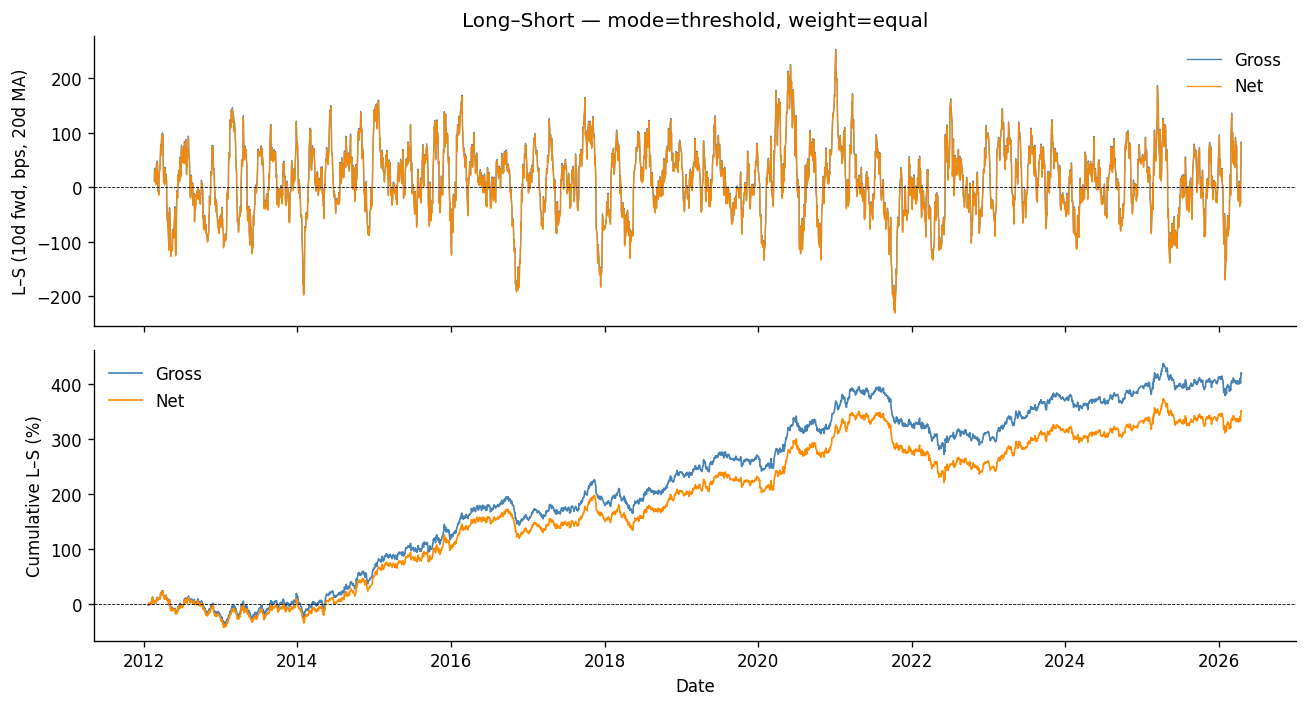

Mean L–S (gross): 12.171 bps/rebalance   t = 2.401
Mean L–S (net)  : 10.171 bps/rebalance   t = 2.006


In [23]:
# Daily L–S spread: gross vs net after simple round-trip cost
cum_ls = ls_daily.cumsum()
cum_net = ls_net.cumsum()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(ls_daily.index, ls_daily.rolling(20).mean() * 1e4, color="steelblue", linewidth=0.8, label="Gross")
axes[0].plot(ls_net.index, ls_net.rolling(20).mean() * 1e4, color="darkorange", linewidth=0.8, alpha=0.9, label="Net")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_ylabel(f"L–S ({HOLDING_DAYS}d fwd, bps, 20d MA)")
axes[0].set_title(f"Long–Short — mode={PORTFOLIO_MODE}, weight={WEIGHTING}")
axes[0].legend(frameon=False, loc="upper right")

axes[1].plot(cum_ls.index, cum_ls.values * 1e2, color="steelblue", linewidth=1, label="Gross")
axes[1].plot(cum_net.index, cum_net.values * 1e2, color="darkorange", linewidth=1, label="Net")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("Cumulative L–S (%)")
axes[1].set_xlabel("Date")
axes[1].legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()


def _t_stat(x: pd.Series) -> float:
    x = x.dropna()
    if len(x) < 2:
        return float("nan")
    return float(x.mean() / (x.std(ddof=1) / np.sqrt(len(x))))


ls_mean = ls_daily.mean() * 1e4
ls_t = _t_stat(ls_daily)
net_mean = ls_net.mean() * 1e4
net_t = _t_stat(ls_net)

print(f"Mean L–S (gross): {ls_mean:.3f} bps/rebalance   t = {ls_t:.3f}")
print(f"Mean L–S (net)  : {net_mean:.3f} bps/rebalance   t = {net_t:.3f}")

---
## Test 4 — ADF Stationarity Test

We run the Augmented Dickey-Fuller test on the **cumulative residual** for each stock:

$$X_{i,t} = \sum_{\tau \leq t} \varepsilon_{i,\tau}$$

The null hypothesis is a unit root (random walk — no mean reversion). Rejecting the null supports stationarity — the cumulative residual tends to revert rather than drift.

This is a supporting test, not the centrepiece. Some stocks may have stationary residuals while others do not.

In [24]:
cum_residuals = residuals.cumsum()
adf_records   = {}

for ticker in tqdm(residuals.columns, desc="ADF"):
    series = cum_residuals[ticker].dropna()
    if len(series) < 50:
        continue
    stat, pval, *_ = adfuller(series, autolag="AIC")
    adf_records[ticker] = {"stat": stat, "pvalue": pval}

adf_df = pd.DataFrame(adf_records).T
_adf_lens = [cum_residuals[c].dropna().shape[0] for c in adf_df.index]

pct_5  = (adf_df["pvalue"] < 0.05).mean()
pct_10 = (adf_df["pvalue"] < 0.10).mean()

print(f"Stocks tested                  : {len(adf_df)}")
print(
    f"ADF cum-ε length (min / median / max) : "
    f"{min(_adf_lens)}, {np.median(_adf_lens):.0f}, {max(_adf_lens)}"
)
print(f"Reject unit root at 5%  level  : {pct_5:.1%}")
print(f"Reject unit root at 10% level  : {pct_10:.1%}")
print(f"Mean ADF statistic             : {adf_df['stat'].mean():.3f}")

ADF: 100%|██████████| 200/200 [00:15<00:00, 12.96it/s]

Stocks tested                  : 200
ADF cum-ε length (min / median / max) : 3608, 3608, 3608
Reject unit root at 5%  level  : 32.0%
Reject unit root at 10% level  : 40.5%
Mean ADF statistic             : -2.263


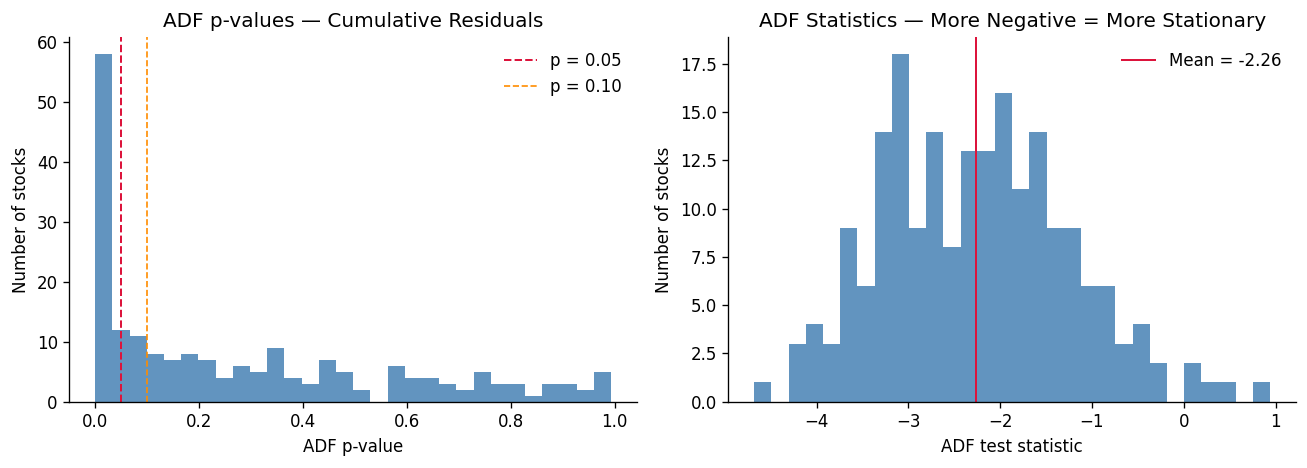

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.hist(adf_df["pvalue"], bins=30, color="steelblue", edgecolor="none", alpha=0.85)
ax.axvline(0.05, color="crimson",  linewidth=1.2, linestyle="--", label="p = 0.05")
ax.axvline(0.10, color="darkorange", linewidth=1.0, linestyle="--", label="p = 0.10")
ax.set_xlabel("ADF p-value")
ax.set_ylabel("Number of stocks")
ax.set_title("ADF p-values — Cumulative Residuals")
ax.legend(frameon=False)

ax = axes[1]
ax.hist(adf_df["stat"], bins=30, color="steelblue", edgecolor="none", alpha=0.85)
ax.axvline(adf_df["stat"].mean(), color="crimson", linewidth=1.2, linestyle="-",
           label=f"Mean = {adf_df['stat'].mean():.2f}")
ax.set_xlabel("ADF test statistic")
ax.set_ylabel("Number of stocks")
ax.set_title("ADF Statistics — More Negative = More Stationary")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

---
## Summary

**Notebook role:** **AR(1)-filtered** tradeable universe (`USE_AR1_UNIVERSE=True`). Compare to the **wide-universe** notebook for breadth vs. confirmation.

Full detail in Test 3. Re-run after parameter changes.



In [26]:
# %% [markdown]
# ---
# ## Summary

# %%
print("=" * 60)
print("MEAN-REVERSION TEST SUMMARY")
print("=" * 60)

# --- Test 1 ---
print("\nTest 1 — Predictive regression (date-clustered SEs)")
specs = [
    ("Return regression      r_{t+1}", fit_r),
    ("Residual regression    ε_{t+1}", fit_e),
]
if fit_r_fe is not None:
    specs.append(("Stock-demeaned y       r̃_{t+1}", fit_r_fe))
if fit_r_H is not None:
    specs.append((f"Horizon-matched        r_{{t+1:t+{HOLDING_DAYS}}}", fit_r_H))
if fit_r_tick is not None:
    specs.append(("Alt SE (cluster ticker)", fit_r_tick))
if globals().get("fit_r_ar1uni") is not None:
    specs.append(("AR(1)-filtered universe", fit_r_ar1uni))

for label, fit in specs:
    b  = fit.params["z_score"]
    t  = fit.tvalues["z_score"]
    p  = fit.pvalues["z_score"]
    r2 = fit.rsquared
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
    print(f"  {label:<38}  b={b:+.6f}{stars:<3}  t={t:+.2f}  p={p:.4f}  R²={r2:.6f}")

# --- Test 2 ---
print("\nTest 2 — AR(1) residual autocorrelation (per stock)")
print(f"  Mean φ                          : {phi_df['phi'].mean():+.4f}")
print(f"  Median φ                        : {phi_df['phi'].median():+.4f}")
print(f"  % φ < 0                         : {(phi_df['phi'] < 0).mean():.1%}")
print(f"  % φ < 0 & p < 0.05             : {sig_neg:.1%}")
print(f"  % φ > 0 & p < 0.05             : {sig_pos:.1%}")
print(f"  AR(1) tradeable (φ<0, p<{AR1_MAX_P}): {len(ar1_tradeable)} tickers")

# --- Test 3 — Long–short portfolio (full detail) ----------
print("\nTest 3 — Long–short portfolio")

print("  Rules (portfolio construction):")
if PORTFOLIO_MODE == "threshold":
    print(f"    • threshold — long tickers with z < -{Z_THRESHOLD}, short tickers with z > +{Z_THRESHOLD}")
elif PORTFOLIO_MODE == "tail_quantile":
    print(f"    • tail_quantile — long bottom {TAIL_Q:.0%}, short top {TAIL_Q:.0%} of the cross-sectional z each day")
else:
    print(f"    • decile — sort z into {N_DECILES} groups; L–S return series uses decile 1 vs decile {N_DECILES}")
print(f"    • weighting within each leg: {WEIGHTING}")

print("  Economics:")
print(f"    • r_trade = sum of the next {HOLDING_DAYS} daily log returns after the signal date (H-day holding)")
print(
    f"    • friction: subtract {ROUND_TRIP_BPS:.1f} bps round-trip per rebalance day from gross L–S "
    f"({COST_BPS_PER_SIDE:.1f} bps/side × 2, applied to the long–short book)"
)

_tc = globals().get("trade_cols", [])
print(f"  Universe: {len(_tc)} tickers in zs_port / r_trade  |  USE_AR1_UNIVERSE={USE_AR1_UNIVERSE}")

print("  Coverage & span:")
if "common_dates" in globals() and len(common_dates) > 1:
    n_slots = len(common_dates) - 1
    print(f"    • candidate rebalance dates (loop): {n_slots:,} (last calendar date excluded in loop)")
else:
    n_slots = None

if "ls_daily" in globals() and len(ls_daily):
    n_f = len(ls_daily)
    pct = f"{100.0 * n_f / n_slots:.1f}%" if n_slots else "n/a"
    print(f"    • days with non-empty long & short legs: {n_f:,} ({pct} of candidates)")
    print(f"    • ls_daily span: {ls_daily.index.min().date()} → {ls_daily.index.max().date()}")

    gross_ann = ls_mean * 252 / HOLDING_DAYS / 100 if np.isfinite(ls_mean) else float("nan")
    net_ann = net_mean * 252 / HOLDING_DAYS / 100 if np.isfinite(net_mean) else float("nan")
    print("  Mean return & significance (daily L–S series, bps/day):")
    print(f"    • gross: {ls_mean:+.3f} bps/day  t = {ls_t:+.3f}  (≈ {gross_ann:+.2f}% ann. with ×252/H scaling)")
    print(f"    • net:   {net_mean:+.3f} bps/day  t = {net_t:+.3f}  (≈ {net_ann:+.2f}% ann.)")
    drag = ls_mean - net_mean
    print(f"    • cost check: mean(gross) − mean(net) = {drag:+.3f} bps/day (target ≈ {ROUND_TRIP_BPS:.1f} bps if one RT/day)")

    g = ls_daily * 1e4
    n = ls_net * 1e4
    qs = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    gq = g.quantile(qs)
    nq = n.quantile(qs)
    print("  Distribution (bps) — gross & net:")
    print("    • percentiles: " + " | ".join(f"p{int(q*100):02d} g={gq[q]:+.1f} n={nq[q]:+.1f}" for q in qs))
    print(f"    • min / max gross: {g.min():+.1f} / {g.max():+.1f}   net: {n.min():+.1f} / {n.max():+.1f}")
    print(f"    • win rate gross / net: {(ls_daily > 0).mean():.1%} / {(ls_net > 0).mean():.1%}")
    print(f"    • std gross / net: {g.std(ddof=1):.2f} / {n.std(ddof=1):.2f} bps")
    print(f"    • skew gross / net: {float(g.skew()):+.2f} / {float(n.skew()):+.2f}")
    print(f"    • excess kurtosis g/n: {float(g.kurtosis()):+.2f} / {float(n.kurtosis()):+.2f}")

    if len(ls_daily) > 2:
        print(
            f"    • AC(1) gross / net: {ls_daily.autocorr(lag=1):+.4f} / {ls_net.autocorr(lag=1):+.4f}"
        )

    cum_g = ls_daily.cumsum()
    cum_n = ls_net.cumsum()
    dd_g = float(((cum_g - cum_g.cummax()) * 1e4).min())
    dd_n = float(((cum_n - cum_n.cummax()) * 1e4).min())
    print(f"  Risk — max drawdown on cumulative Σ log L–S vs running peak (bps): gross {dd_g:.1f}  net {dd_n:.1f}")

    sg = float(ls_daily.std(ddof=1))
    sn = float(ls_net.std(ddof=1))
    sh_g = (ls_daily.mean() / sg * np.sqrt(252)) if sg > 0 else float("nan")
    sh_n = (ls_net.mean() / sn * np.sqrt(252)) if sn > 0 else float("nan")
    print(
        f"  Naive Sharpe (√252·mean/std on daily L–S): gross {sh_g:+.2f}  net {sh_n:+.2f}  "
        f"(descriptive only: {HOLDING_DAYS}-day overlapping holds ⇒ not i.i.d.)"
    )

    if PORTFOLIO_MODE == "decile" and globals().get("decile_mean") is not None and len(decile_mean):
        try:
            spread = float(decile_mean.iloc[0] - decile_mean.iloc[-1])
            print(f"  Decile snapshot: D1–D{N_DECILES} mean-return spread = {spread:+.2f} bps")
        except Exception:
            pass
else:
    print("  (No ls_daily — run the portfolio construction cell first.)")

# --- Test 4 ---
print("\nTest 4 — ADF stationarity (full-sample cumulative ε per stock)")
print(f"  Stocks tested             : {len(adf_df)}")
print(f"  Reject unit root @ 5%     : {pct_5:.1%}")
print(f"  Reject unit root @ 10%    : {pct_10:.1%}")
print(f"  Mean ADF statistic        : {adf_df['stat'].mean():.3f}")

# --- Config snapshot ---
print("\nConfig snapshot")
print(f"  PCA suffix      : {PCA_OUTPUT_SUFFIX}")
print(f"  HOLDING_DAYS    : {HOLDING_DAYS}")
print(f"  PORTFOLIO_MODE  : {PORTFOLIO_MODE}  Z_THRESHOLD={Z_THRESHOLD}  TAIL_Q={TAIL_Q}")
print(f"  WEIGHTING       : {WEIGHTING}  INV_VOL_LOOKBACK={INV_VOL_LOOKBACK}")
print(f"  USE_AR1_UNIVERSE: {USE_AR1_UNIVERSE}  AR1_MAX_P={AR1_MAX_P}")
print(f"  COST_BPS/side   : {COST_BPS_PER_SIDE}")
print(f"  Panel obs       : {len(panel):,}  |  date range: {panel['date'].min().date()} → {panel['date'].max().date()}")

print("\n" + "=" * 60)

MEAN-REVERSION TEST SUMMARY

Test 1 — Predictive regression (date-clustered SEs)
  Return regression      r_{t+1}          b=-0.000082***  t=-4.21  p=0.0000  R²=0.000029
  Residual regression    ε_{t+1}          b=-0.000085***  t=-5.59  p=0.0000  R²=0.000081
  Stock-demeaned y       r̃_{t+1}         b=-0.000082***  t=-4.23  p=0.0000  R²=0.000029
  Horizon-matched        r_{t+1:t+10}     b=-0.000079     t=-1.47  p=0.1404  R²=0.000003
  AR(1)-filtered universe                 b=-0.000259***  t=-8.24  p=0.0000  R²=0.000332

Test 2 — AR(1) residual autocorrelation (per stock)
  Mean φ                          : -0.0165
  Median φ                        : -0.0171
  % φ < 0                         : 75.5%
  % φ < 0 & p < 0.05             : 25.5%
  % φ > 0 & p < 0.05             : 2.0%
  AR(1) tradeable (φ<0, p<0.1): 67 tickers

Test 3 — Long–short portfolio
  Rules (portfolio construction):
    • threshold — long tickers with z < -1.5, short tickers with z > +1.5
    • weighting within each 